# Lab 10: Learning the XOR Boolean Function Using an MLP

## The XOR Problem

| Input 1 | Input 2 | XOR Output |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |


## Step 1: Create the Dataset


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # keep TensorFlow's console logs quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
SEED = 42

# XOR dataset: 4 possible input combinations
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

xor_table = pd.DataFrame(np.hstack([X, y]), columns=['Input 1', 'Input 2', 'XOR Output'])
display(xor_table)

,Input 1,Input 2,XOR Output
0,0.0,0.0,0.0
1,0.0,1.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0


## Part A: Keras (TensorFlow High-Level API)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

keras_model = keras.Sequential([
    layers.Dense(4, activation='tanh', input_shape=(2,), name='hidden_layer'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
EPOCHS = 500

keras_history = keras_model.fit(X, y, epochs=EPOCHS, verbose=0)

keras_loss, keras_acc = keras_model.evaluate(X, y, verbose=0)
print(f'Final training loss:     {keras_loss:.4f}')
print(f'Final training accuracy: {keras_acc:.2%}')

keras_probs = keras_model.predict(X, verbose=0)
keras_preds = (keras_probs > 0.5).astype(int)

keras_results = pd.DataFrame({
    'Input 1': X[:, 0].astype(int),
    'Input 2': X[:, 1].astype(int),
    'Actual XOR': y.flatten().astype(int),
    'Predicted Probability': keras_probs.flatten().round(4),
    'Predicted Class': keras_preds.flatten()
})
display(keras_results)

Final training loss:     0.3468
Final training accuracy: 50.00%


,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted Class
0,0,0,0,0.0001,0
1,0,1,1,0.9998,1
2,1,0,1,0.4999,0
3,1,1,0,0.5001,1


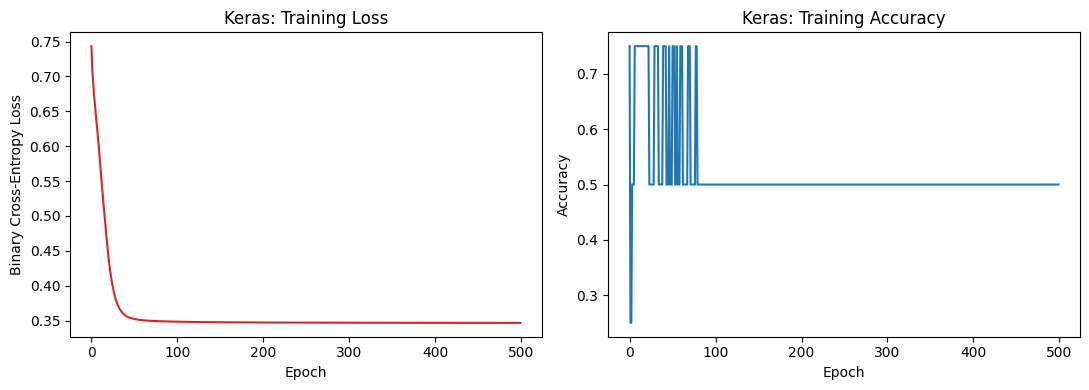

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(keras_history.history['loss'], color='tab:red')
axes[0].set(title='Keras: Training Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy Loss')
axes[1].plot(keras_history.history['accuracy'], color='tab:blue')
axes[1].set(title='Keras: Training Accuracy', xlabel='Epoch', ylabel='Accuracy')
plt.tight_layout()
plt.show()

**Interpretation:** The loss barely drops and accuracy stays near 50% — Keras got stuck in this run and didn't fully learn XOR. This can happen when random initialization sends training toward a bad point it can't escape.

## Part B: PyTorch

In [5]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)

X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

class XORNet(nn.Module):
    def __init__(self, hidden_neurons=4):
        super().__init__()
        self.hidden = nn.Linear(2, hidden_neurons)
        self.tanh = nn.Tanh()
        self.output = nn.Linear(hidden_neurons, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.tanh(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

torch_model = XORNet(hidden_neurons=4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.1)
print(torch_model)

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (tanh): Tanh()
  (output): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [6]:
torch_losses = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    outputs = torch_model(X_torch)
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())

print(f'Final training loss: {torch_losses[-1]:.4f}')

Final training loss: 0.0009


In [7]:
with torch.no_grad():
    torch_probs = torch_model(X_torch).numpy()
torch_preds = (torch_probs > 0.5).astype(int)
torch_acc = (torch_preds.flatten() == y.flatten()).mean()
print(f'Final training accuracy: {torch_acc:.2%}')

torch_results = pd.DataFrame({
    'Input 1': X[:, 0].astype(int),
    'Input 2': X[:, 1].astype(int),
    'Actual XOR': y.flatten().astype(int),
    'Predicted Probability': torch_probs.flatten().round(4),
    'Predicted Class': torch_preds.flatten()
})
display(torch_results)

Final training accuracy: 100.00%


,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted Class
0,0,0,0,0.0000,0
1,0,1,1,0.9990,1
2,1,0,1,0.9990,1
3,1,1,0,0.0016,0


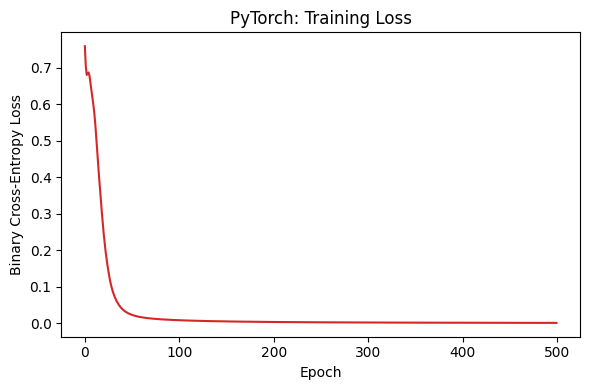

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(torch_losses, color='tab:red')
plt.title('PyTorch: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.tight_layout()
plt.show()

**Interpretation:** Unlike Keras above, PyTorch's loss drops close to 0 and it correctly learns XOR (100% accuracy). The only real difference is we wrote the training loop by hand instead of calling `.fit()`.

## Part C: TensorFlow Low-Level API


In [9]:
tf.random.set_seed(SEED)

# Manually created weights and biases (this is what Dense layers do internally)
W1 = tf.Variable(tf.random.normal([2, 4], stddev=1.0, seed=SEED), name='W1')
b1 = tf.Variable(tf.zeros([4]), name='b1')
W2 = tf.Variable(tf.random.normal([4, 1], stddev=1.0, seed=SEED), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

def forward(x):
    hidden = tf.tanh(tf.matmul(x, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def bce_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # avoid log(0)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

tf_optimizer = tf.optimizers.Adam(learning_rate=0.1)
print('Trainable variables: W1, b1, W2, b2')

Trainable variables: W1, b1, W2, b2


In [10]:
tf_losses = []

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        preds = forward(X_tf)
        loss = bce_loss(y_tf, preds)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    tf_optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    tf_losses.append(float(loss))

print(f'Final training loss: {tf_losses[-1]:.4f}')

Final training loss: 0.0005


In [11]:
tf_probs = forward(X_tf).numpy()
tf_preds = (tf_probs > 0.5).astype(int)
tf_acc = (tf_preds.flatten() == y.flatten()).mean()
print(f'Final training accuracy: {tf_acc:.2%}')

tf_results = pd.DataFrame({
    'Input 1': X[:, 0].astype(int),
    'Input 2': X[:, 1].astype(int),
    'Actual XOR': y.flatten().astype(int),
    'Predicted Probability': tf_probs.flatten().round(4),
    'Predicted Class': tf_preds.flatten()
})
display(tf_results)

Final training accuracy: 100.00%


,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted Class
0,0,0,0,0.0000,0
1,0,1,1,0.9995,1
2,1,0,1,0.9993,1
3,1,1,0,0.0009,0


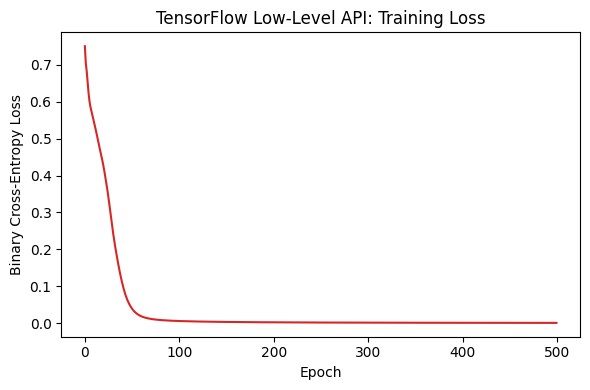

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(tf_losses, color='tab:red')
plt.title('TensorFlow Low-Level API: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.tight_layout()
plt.show()

**Interpretation:** This hand-built version also reaches 100% accuracy.

## Step 5: Comparing the Three Implementations

,Library,Final Loss,Final Accuracy
0,Keras,0.3468,50%
1,PyTorch,0.0009,100%
2,TensorFlow (low-level),0.0005,100%


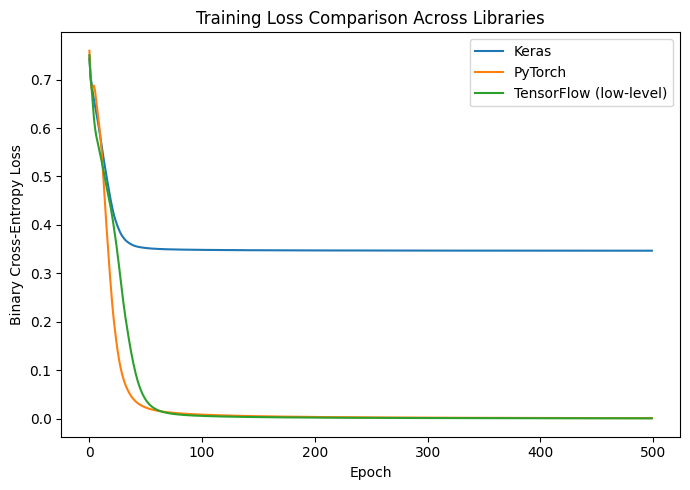

In [13]:
comparison = pd.DataFrame({
    'Library': ['Keras', 'PyTorch', 'TensorFlow (low-level)'],
    'Final Loss': [keras_loss, torch_losses[-1], tf_losses[-1]],
    'Final Accuracy': [keras_acc, torch_acc, tf_acc]
})
comparison['Final Accuracy'] = comparison['Final Accuracy'].apply(lambda a: f'{a:.0%}')
display(comparison.round({'Final Loss': 4}))

plt.figure(figsize=(7, 5))
plt.plot(keras_history.history['loss'], label='Keras')
plt.plot(torch_losses, label='PyTorch')
plt.plot(tf_losses, label='TensorFlow (low-level)')
plt.title('Training Loss Comparison Across Libraries')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** PyTorch and low-level TensorFlow both learned XOR perfectly (100% accuracy, loss near 0). Keras got stuck at 50% in this run

## Optional: Decision Boundary Plots



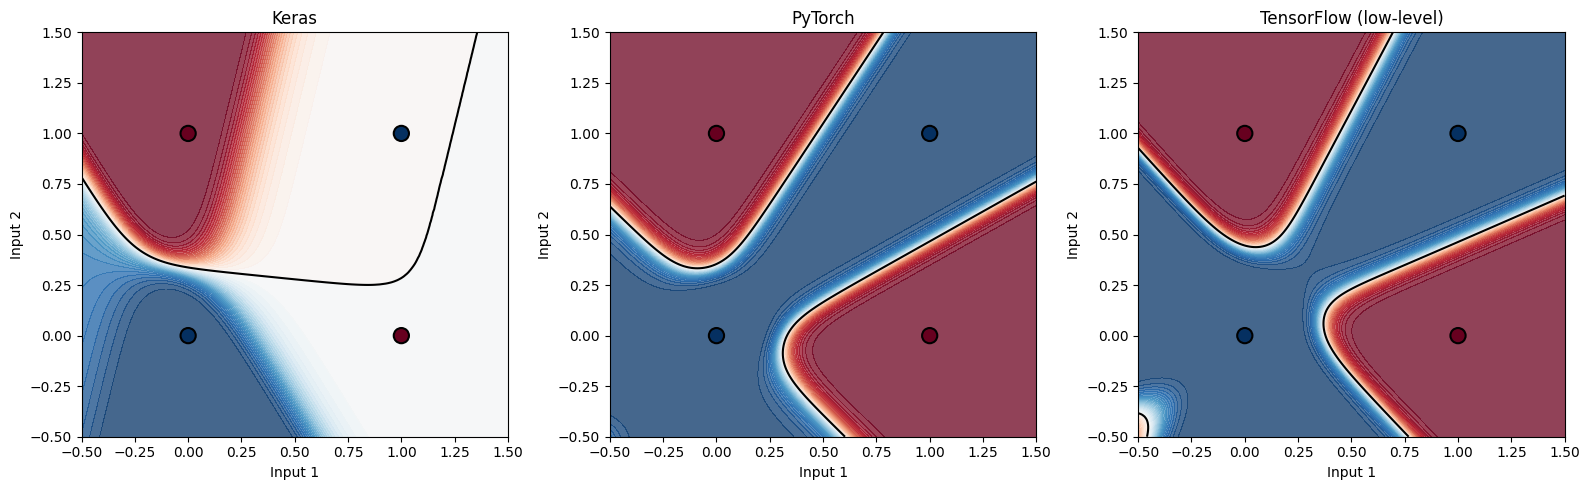

In [14]:
def plot_decision_boundary(predict_fn, title, ax):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    probs = predict_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdBu_r', edgecolors='black', s=120, linewidths=1.5, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')

def keras_predict(grid):
    return keras_model.predict(grid, verbose=0)

def torch_predict(grid):
    with torch.no_grad():
        return torch_model(torch.tensor(grid, dtype=torch.float32)).numpy()

def tf_predict(grid):
    return forward(tf.constant(grid, dtype=tf.float32)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_decision_boundary(keras_predict, 'Keras', axes[0])
plot_decision_boundary(torch_predict, 'PyTorch', axes[1])
plot_decision_boundary(tf_predict, 'TensorFlow (low-level)', axes[2])
plt.tight_layout()
plt.show()

**Interpretation:** The black line marks where a model's prediction flips from 0 to 1. For PyTorch and TensorFlow, it bends to correctly separate the red points from the blue ones — a straight line could never do that. Keras' boundary looks off here since it didn't fully learn XOR in this run.